# SC MA2021 General

薄入口 notebook：导入 NEURON 与 BrainCell 的 SC cell，配置机制开关，添加刺激与 probe，运行并比较 soma 和全 compartment 电压。

In [1]:
from pathlib import Path
import sys
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import brainunit as u
from neuron import h

def find_repo_root(start=None):
    cwd = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "braincell").exists() and (candidate / "examples").exists():
            return candidate
    raise RuntimeError("Run this notebook from the repository root or a subdirectory inside it.")

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.neuron_compare.cell.sc_ma2021.debug.sc_parameters import (
    DEFAULT_MORPH_PATH,
    DEFAULT_NRNMECH_PATH,
    SCConfig,
    SCToggles,
    load_sc21_params,
    toggle_names,
)
from examples.neuron_compare.cell.sc_ma2021.debug.sc_neuron_debug import SC as NeuronSC
from examples.neuron_compare.cell.sc_ma2021.debug.sc_braincell_debug import SC as BrainCellSC

import braincell
from braincell import mech
from braincell.filter import at
print("braincell import:", braincell.__file__)
import brainstate
brainstate.environ.set(precision=64)

--No graphics will be displayed.


braincell import: /home/swl/braincell-ion_dyn/braincell/__init__.py


In [2]:
params = load_sc21_params()

# Presets: "all", "leak_only", "calcium_only", "cdp_calcium", "manual".
# Use "manual" when you want direct control of every channel/ion below.
toggle_mode = "manual"

# Passive current.
leak = True

# Sodium channels. Source SC_param.py currently sets both Na conductances to zero.
nav1p1 = True
nav1p6 = True

# Calcium channels.
cav2p1 = True
cav3p2 =  True
cav3p3 = True

# Potassium channels.
kir2p3 = True
kv1p1 = True
kv3p4 = True
kv4p3 = True
km = True

# Calcium-activated potassium channels.
kca1p1 = True
kca2p2 = True

# HCN channels.
hcn1 = True

# Calcium ion/pool. When False, calcium-dependent/channel tests use CalciumFixed if needed.
cdp = True

manual_toggles = {
    "leak": leak,
    "nav1p1": nav1p1,
    "nav1p6": nav1p6,
    "cav2p1": cav2p1,
    "cav3p2": cav3p2,
    "cav3p3": cav3p3,
    "kir2p3": kir2p3,
    "kv1p1": kv1p1,
    "kv3p4": kv3p4,
    "kv4p3": kv4p3,
    "km": km,
    "kca1p1": kca1p1,
    "kca2p2": kca2p2,
    "hcn1": hcn1,
    "cdp": cdp,
}

def make_toggles(mode="all", **overrides):
    names = toggle_names()
    if mode == "all":
        values = {name: True for name in names}
    elif mode == "leak_only":
        values = {name: False for name in names}
        values["leak"] = True
    elif mode == "calcium_only":
        values = {name: False for name in names}
        values.update({"leak": True, "cav2p1": True, "cav3p2": True, "cav3p3": True})
    elif mode == "cdp_calcium":
        values = {name: False for name in names}
        values.update({"leak": True, "cav2p1": True, "cav3p2": True, "cav3p3": True, "cdp": True})
    elif mode == "manual":
        values = {name: bool(manual_toggles.get(name, False)) for name in names}
    else:
        raise ValueError(f"Unknown toggle_mode {mode!r}.")
    values.update({key: bool(value) for key, value in overrides.items()})
    return SCToggles(**values)

# Example override: make_toggles("all", cav3p3=False, cdp=False)
toggles = make_toggles(toggle_mode)
config = SCConfig(toggles=toggles, temperature_celsius=32.0, v_init_mV=-65.0)

dt_ms = 0.1
duration_ms = 100.0
delay_ms = 10.0
stim_dur_ms = 80.0
amp_nA = 0.05

# Soma diagnostic channel. Choices: "cav2p1", "cav3p2", "cav3p3", None.
diag_channel = "cav3p3"
soma_diag_config = {
    "channel": diag_channel,
    "ica": bool(diag_channel and getattr(toggles, diag_channel)),
    "cai": bool(toggles.cdp),
    "cao": bool(toggles.cdp),
    "gates": bool(diag_channel and getattr(toggles, diag_channel)),
}

display(pd.DataFrame(
    [
        {"group": "passive", "name": "leak", "enabled": toggles.leak},
        {"group": "sodium", "name": "nav1p1", "enabled": toggles.nav1p1},
        {"group": "sodium", "name": "nav1p6", "enabled": toggles.nav1p6},
        {"group": "calcium_channel", "name": "cav2p1", "enabled": toggles.cav2p1},
        {"group": "calcium_channel", "name": "cav3p2", "enabled": toggles.cav3p2},
        {"group": "calcium_channel", "name": "cav3p3", "enabled": toggles.cav3p3},
        {"group": "potassium", "name": "kir2p3", "enabled": toggles.kir2p3},
        {"group": "potassium", "name": "kv1p1", "enabled": toggles.kv1p1},
        {"group": "potassium", "name": "kv3p4", "enabled": toggles.kv3p4},
        {"group": "potassium", "name": "kv4p3", "enabled": toggles.kv4p3},
        {"group": "potassium", "name": "km", "enabled": toggles.km},
        {"group": "kca", "name": "kca1p1", "enabled": toggles.kca1p1},
        {"group": "kca", "name": "kca2p2", "enabled": toggles.kca2p2},
        {"group": "hcn", "name": "hcn1", "enabled": toggles.hcn1},
        {"group": "ion", "name": "cdp", "enabled": toggles.cdp},
    ]
))

,group,name,enabled
0,passive,leak,True
1,sodium,nav1p1,True
2,sodium,nav1p6,True
3,calcium_channel,cav2p1,True
4,calcium_channel,cav3p2,True
5,calcium_channel,cav3p3,True
6,potassium,kir2p3,True
7,potassium,kv1p1,True
8,potassium,kv3p4,True
9,potassium,kv4p3,True


In [3]:
neuron_sc = NeuronSC(
    DEFAULT_MORPH_PATH,
    params=params,
    config=config,
    nrnmech_path=DEFAULT_NRNMECH_PATH,
).build()
braincell_sc = BrainCellSC(
    DEFAULT_MORPH_PATH,
    params=params,
    config=config,
).build()

display(pd.Series(neuron_sc.summary(), dtype=object))
display(pd.Series(braincell_sc.summary(), dtype=object))
display(neuron_sc.branch_table().head())
display(braincell_sc.branch_table().head())
display(neuron_sc.branch_table()["source_region"].value_counts().sort_index())
display(braincell_sc.branch_table()["source_region"].value_counts().sort_index())


4282 lines read
217 spines


/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [13]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [11]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [33]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell-ion_dyn/braincell/io/asc/reader.py:584: UserWarning: from_p

backend                                                          neuron
morph_path            /home/swl/braincell-ion_dyn/examples/neuron_co...
toggles               {'leak': True, 'nav1p1': True, 'nav1p6': True,...
branch_counts         {'n_soma': 1, 'n_dend': 104, 'n_axon': 15, 'n_...
region_counts         {'axon_ais': 1, 'axon_regular': 14, 'denddist'...
compartment_counts                                {'n_total_nseg': 130}
enabled_mechanisms    {'soma': ['leak', 'nav1p1', 'cav3p2', 'cav3p3'...
dtype: object

backend                                                       braincell
morph_path            /home/swl/braincell-ion_dyn/examples/neuron_co...
frozen                                                             True
toggles               {'leak': True, 'nav1p1': True, 'nav1p6': True,...
branch_counts         {'n_soma': 1, 'n_dend': 104, 'n_axon': 15, 'n_...
region_counts         {'axon_ais': 1, 'axon_regular': 14, 'denddist'...
compartment_counts                                  {'n_total_cv': 130}
enabled_mechanisms    {'soma': ['leak', 'nav1p1', 'cav3p2', 'cav3p3'...
dtype: object

,branch_index,branch_name,branch_type,source_region,source_local_index,diam_um,diam_arc_mean_um,cm_uF_cm2,nseg,has_cav2p1,...,has_kca2p2,has_kir2p3,has_km,has_kv1p1,has_kv3p4,has_kv4p3,has_leak,has_nav1p1,has_nav1p6,enabled_mechanisms
0,0,soma[0],soma,soma,0,6.895987,6.895987,1.0,1,True,...,True,True,False,True,True,True,True,True,False,"[cav2p1, cav3p2, cav3p3, cdp, hcn1, kca1p1, kc..."
1,1,axon[0],axon,axon_ais,0,0.407269,0.407269,1.0,1,False,...,False,False,True,True,True,False,True,False,True,"[cdp, hcn1, km, kv1p1, kv3p4, leak, nav1p6]"
2,2,axon[1],axon,axon_regular,1,0.371386,0.371386,1.0,1,False,...,False,False,False,True,True,False,True,False,True,"[cdp, hcn1, kv1p1, kv3p4, leak, nav1p6]"
3,3,axon[2],axon,axon_regular,2,0.403675,0.403675,1.0,1,False,...,False,False,False,True,True,False,True,False,True,"[cdp, hcn1, kv1p1, kv3p4, leak, nav1p6]"
4,4,axon[3],axon,axon_regular,3,0.374403,0.374403,1.0,1,False,...,False,False,False,True,True,False,True,False,True,"[cdp, hcn1, kv1p1, kv3p4, leak, nav1p6]"


,branch_index,branch_name,branch_type,source_region,source_local_index,diam_arc_mean_um,cm_uF_cm2,n_cv,has_cav2p1,has_cav3p2,...,has_kca2p2,has_kir2p3,has_km,has_kv1p1,has_kv3p4,has_kv4p3,has_leak,has_nav1p1,has_nav1p6,enabled_mechanisms
0,0,soma,soma,soma,0,6.895987,1.0,1,True,True,...,True,True,False,True,True,True,True,True,False,"[cav2p1, cav3p2, cav3p3, cdp, hcn1, kca1p1, kc..."
1,1,axon_0,axon,axon_ais,0,0.407269,1.0,1,False,False,...,False,False,True,True,True,False,True,False,True,"[cdp, hcn1, km, kv1p1, kv3p4, leak, nav1p6]"
2,2,axon_1,axon,axon_regular,1,0.371386,1.0,1,False,False,...,False,False,False,True,True,False,True,False,True,"[cdp, hcn1, kv1p1, kv3p4, leak, nav1p6]"
3,3,axon_2,axon,axon_regular,2,0.403674,1.0,1,False,False,...,False,False,False,True,True,False,True,False,True,"[cdp, hcn1, kv1p1, kv3p4, leak, nav1p6]"
4,4,axon_3,axon,axon_regular,3,0.374403,1.0,1,False,False,...,False,False,False,True,True,False,True,False,True,"[cdp, hcn1, kv1p1, kv3p4, leak, nav1p6]"


source_region
axon_ais         1
axon_regular    14
denddist        90
dendprox        14
soma             1
Name: count, dtype: int64

source_region
axon_ais         1
axon_regular    14
denddist        90
dendprox        14
soma             1
Name: count, dtype: int64

In [4]:
nrn_voltage_probes = neuron_sc.attach_voltage_probes(all_compartments=True, soma=True)
bc_voltage_probes = braincell_sc.attach_voltage_probes(all_compartments=True, soma=True)

DIAGNOSTIC_CHANNELS = {
    "cav2p1": {
        "neuron_mech": "Cav2p1_RI21_SC",
        "braincell_mech": "Cav2p1_soma",
        "label": r"$I_{CaV2.1}$",
        "gates": (("m", "m"),),
    },
    "cav3p2": {
        "neuron_mech": "Cav3p2_RI21_SC",
        "braincell_mech": "Cav3p2_soma",
        "label": r"$I_{CaV3.2}$",
        "gates": (("m", "m"), ("h", "h")),
    },
    "cav3p3": {
        "neuron_mech": "Cav3p3_RI21_SC",
        "braincell_mech": "Cav3p3_soma",
        "label": r"$I_{CaV3.3}$",
        "gates": (("n", "n"), ("l", "l")),
    },
}

def attach_soma_diagnostics(neuron_sc, braincell_sc, enabled):
    handles = {}
    channel_key = enabled.get("channel")
    if not channel_key:
        return handles
    spec = DIAGNOSTIC_CHANNELS[channel_key]
    nrn_seg = neuron_sc.root_soma(0.5)
    nrn_mech = getattr(nrn_seg, spec["neuron_mech"])
    bc_mech_name = spec["braincell_mech"]
    ca_name = braincell_sc._ca_name("soma")
    handles["channel"] = channel_key
    handles["label"] = spec["label"]
    if enabled.get("ica", False):
        handles["ica_neuron"] = h.Vector().record(nrn_mech._ref_ica)
        braincell_sc.cell.place(at("soma", 0.5), mech.CurrentProbe(ion=ca_name, mechanism=bc_mech_name))
        handles["ica_braincell_trace"] = f"soma(0.5)_{bc_mech_name}_current"
    if enabled.get("cai", False):
        handles["cai_neuron"] = h.Vector().record(nrn_seg._ref_cai)
        braincell_sc.cell.place(at("soma", 0.5), mech.MechanismProbe(mechanism=ca_name, field="Ci"))
        handles["cai_braincell_trace"] = f"soma(0.5)_{ca_name}_Ci"
    if enabled.get("cao", False):
        handles["cao_neuron"] = h.Vector().record(nrn_seg._ref_cao)
        braincell_sc.cell.place(at("soma", 0.5), mech.MechanismProbe(mechanism=ca_name, field="Co"))
        handles["cao_braincell_trace"] = f"soma(0.5)_{ca_name}_Co"
    if enabled.get("gates", False):
        handles["gates"] = []
        for nrn_gate, bc_gate in spec["gates"]:
            handles[f"{bc_gate}_neuron"] = h.Vector().record(getattr(nrn_mech, f"_ref_{nrn_gate}"))
            braincell_sc.cell.place(at("soma", 0.5), mech.MechanismProbe(mechanism=bc_mech_name, field=bc_gate))
            handles[f"{bc_gate}_braincell_trace"] = f"soma(0.5)_{bc_mech_name}_{bc_gate}"
            handles["gates"].append(bc_gate)
    return handles

soma_diag_handles = attach_soma_diagnostics(neuron_sc, braincell_sc, soma_diag_config)

In [5]:
stim = h.IClamp(neuron_sc.root_soma(0.5))
stim.delay = delay_ms
stim.dur = stim_dur_ms
stim.amp = amp_nA
h.cvode_active(0)
h.dt = dt_ms
h.steps_per_ms = 1.0 / h.dt
h.celsius = config.temperature_celsius
h.tstop = duration_ms
h.v_init = config.v_init_mV
t_neuron = h.Vector().record(h._ref_t)
h.finitialize(h.v_init)
h.run()

braincell_sc.cell.place(
    at("soma", 0.5),
    mech.CurrentClamp.step(amp_nA * u.nA, stim_dur_ms * u.ms, delay=delay_ms * u.ms),
)
braincell_sc.cell.init_state()
nrn_seg = neuron_sc.root_soma(0.5)
needs_ca = any([
    toggles.cav2p1,
    toggles.cav3p2,
    toggles.cav3p3,
    toggles.kca1p1,
    toggles.kca2p2,
])
ca_name = braincell_sc._ca_name("soma") if (toggles.cdp or needs_ca) else None
if ca_name is not None:
    bc_ca = braincell_sc.cell.get_ion(ca_name)
    ca_diagnostic = {
        "neuron_eca_mV": float(nrn_seg.eca) if hasattr(nrn_seg, "eca") else None,
        "neuron_cai_mM": float(nrn_seg.cai) if hasattr(nrn_seg, "cai") else None,
        "neuron_cao_mM": float(nrn_seg.cao) if hasattr(nrn_seg, "cao") else None,
        "braincell_ca_name": ca_name,
        "braincell_ca_type": type(bc_ca).__name__,
        "braincell_Ci_mM": float(np.asarray(bc_ca.Ci.value.to_decimal(u.mM), dtype=float).reshape(-1)[0]) if hasattr(bc_ca.Ci, "value") else float(np.asarray(bc_ca.Ci.to_decimal(u.mM), dtype=float).reshape(-1)[0]),
        "braincell_Co_mM": float(np.asarray(bc_ca.Co.to_decimal(u.mM), dtype=float).reshape(-1)[0]),
    }
    display(ca_diagnostic)
braincell_sc.cell.reset_state()
bc_run = braincell_sc.cell.run(dt=dt_ms * u.ms, duration=duration_ms * u.ms)

{'neuron_eca_mV': 126.82113478660835,
 'neuron_cai_mM': 0.00012945417916755965,
 'neuron_cao_mM': 2.0,
 'braincell_ca_name': 'ca_soma',
 'braincell_ca_type': 'CdpStC_RI2021_SC',
 'braincell_Ci_mM': 4.5e-05,
 'braincell_Co_mM': 2.0}

In [6]:
nrn_v = neuron_sc.collect_voltage_results(nrn_voltage_probes)
bc_v = braincell_sc.collect_voltage_results(bc_voltage_probes, bc_run)

reference_time_ms = np.round(np.arange(0.0, duration_ms, dt_ms, dtype=float), decimals=12)
neuron_time_raw = np.asarray(t_neuron, dtype=float).reshape(-1)

def trim_neuron_trace(values, reference_time_ms):
    values = np.asarray(values, dtype=float).reshape(-1)
    if values.shape[0] == reference_time_ms.shape[0] + 1:
        return values[1:]
    return values

def trim_current_pair(neuron_values, braincell_values):
    neuron_values = np.asarray(neuron_values, dtype=float).reshape(-1)
    braincell_values = np.asarray(braincell_values, dtype=float).reshape(-1)
    neuron_values = neuron_values[2:]
    braincell_values = braincell_values[:-1]
    n = min(neuron_values.shape[0], braincell_values.shape[0])
    return neuron_values[:n], braincell_values[:n]

neuron_soma = trim_neuron_trace(nrn_v["soma_voltage_mV"], reference_time_ms)
if nrn_v["compartment_voltage_mV"].shape[0] == reference_time_ms.shape[0] + 1:
    neuron_comp = nrn_v["compartment_voltage_mV"][1:, :]
else:
    neuron_comp = nrn_v["compartment_voltage_mV"]
braincell_soma = bc_v["soma_voltage_mV"]
braincell_comp = bc_v["compartment_voltage_mV"]

soma_diag = {}
if "ica_neuron" in soma_diag_handles:
    neuron_ica_raw = -np.asarray(soma_diag_handles["ica_neuron"], dtype=float).reshape(-1)
    braincell_ica_raw = np.asarray(bc_run.traces[soma_diag_handles["ica_braincell_trace"]].to_decimal(u.mA / (u.cm ** 2)), dtype=float).reshape(-1)
    neuron_ica_mA_cm2, braincell_ica_mA_cm2 = trim_current_pair(neuron_ica_raw, braincell_ica_raw)
    current_time_ms = reference_time_ms[:braincell_ica_mA_cm2.shape[0]]
    soma_diag["ica"] = (neuron_ica_mA_cm2, braincell_ica_mA_cm2, "mA/cm^2", current_time_ms)
if "cai_neuron" in soma_diag_handles:
    neuron_cai_mM = trim_neuron_trace(soma_diag_handles["cai_neuron"], reference_time_ms)
    braincell_cai_mM = np.asarray(bc_run.traces[soma_diag_handles["cai_braincell_trace"]].to_decimal(u.mM), dtype=float).reshape(-1)
    n = min(neuron_cai_mM.shape[0], braincell_cai_mM.shape[0])
    soma_diag["cai"] = (neuron_cai_mM[:n], braincell_cai_mM[:n], "mM", reference_time_ms[:n])
if "cao_neuron" in soma_diag_handles:
    neuron_cao_mM = trim_neuron_trace(soma_diag_handles["cao_neuron"], reference_time_ms)
    braincell_cao_mM = np.asarray(bc_run.traces[soma_diag_handles["cao_braincell_trace"]].to_decimal(u.mM), dtype=float).reshape(-1)
    n = min(neuron_cao_mM.shape[0], braincell_cao_mM.shape[0])
    soma_diag["cao"] = (neuron_cao_mM[:n], braincell_cao_mM[:n], "mM", reference_time_ms[:n])
for key in soma_diag_handles.get("gates", []):
    nrn_key = f"{key}_neuron"
    bc_key = f"{key}_braincell_trace"
    if nrn_key in soma_diag_handles:
        neuron_gate = trim_neuron_trace(soma_diag_handles[nrn_key], reference_time_ms)
        braincell_gate = np.asarray(bc_run.traces[soma_diag_handles[bc_key]], dtype=float).reshape(-1)
        n = min(neuron_gate.shape[0], braincell_gate.shape[0])
        soma_diag[key] = (neuron_gate[:n], braincell_gate[:n], "", reference_time_ms[:n])

def metric_dict(a, b):
    delta = np.asarray(b) - np.asarray(a)
    return {
        "rmse": float(np.sqrt(np.mean(delta ** 2))),
        "max_abs": float(np.max(np.abs(delta))),
        "mean_abs": float(np.mean(np.abs(delta))),
    }

delta_soma = braincell_soma - neuron_soma
soma_summary = {
    "voltage_rmse_mV": float(np.sqrt(np.mean(delta_soma ** 2))),
    "voltage_max_abs_mV": float(np.max(np.abs(delta_soma))),
    "voltage_mean_abs_mV": float(np.mean(np.abs(delta_soma))),
}
for key, values in soma_diag.items():
    neuron_values, braincell_values, unit_label = values[:3]
    stats = metric_dict(neuron_values, braincell_values)
    suffix = unit_label if unit_label else "unitless"
    soma_summary[f"{key}_rmse_{suffix}"] = stats["rmse"]
    soma_summary[f"{key}_max_abs_{suffix}"] = stats["max_abs"]
    soma_summary[f"{key}_mean_abs_{suffix}"] = stats["mean_abs"]

display(pd.Series(soma_summary, dtype=float))

voltage_rmse_mV         4.530280e-03
voltage_max_abs_mV      5.845911e-02
voltage_mean_abs_mV     1.347874e-03
ica_rmse_mA/cm^2        2.166119e-13
ica_max_abs_mA/cm^2     1.099884e-12
ica_mean_abs_mA/cm^2    1.116985e-13
cai_rmse_mM             4.070654e-07
cai_max_abs_mM          2.413442e-06
cai_mean_abs_mM         1.409136e-07
cao_rmse_mM             0.000000e+00
cao_max_abs_mM          0.000000e+00
cao_mean_abs_mM         0.000000e+00
n_rmse_unitless         7.213025e-06
n_max_abs_unitless      3.431861e-05
n_mean_abs_unitless     4.091149e-06
l_rmse_unitless         3.472817e-07
l_max_abs_unitless      6.193738e-07
l_mean_abs_unitless     2.963243e-07
dtype: float64

In [7]:
pair_table = pd.merge(
    bc_v["compartment_table"],
    nrn_v["compartment_table"],
    on=["source_region", "source_local_index", "local_index"],
    suffixes=("_braincell", "_neuron"),
)
metric_rows = []
for row in pair_table.itertuples(index=False):
    bc_idx = int(row.compartment_index_braincell)
    nrn_idx = int(row.compartment_index_neuron)
    delta = braincell_comp[:, bc_idx] - neuron_comp[:, nrn_idx]
    metric_rows.append(
        {
            "source_region": row.source_region,
            "source_local_index": int(row.source_local_index),
            "local_index": int(row.local_index),
            "branch_name_braincell": row.branch_name_braincell,
            "branch_name_neuron": row.branch_name_neuron,
            "mean_abs_mV": float(np.mean(np.abs(delta))),
            "rmse_mV": float(np.sqrt(np.mean(delta ** 2))),
            "max_abs_mV": float(np.max(np.abs(delta))),
        }
    )
compartment_metrics = pd.DataFrame(metric_rows)
display(compartment_metrics.sort_values("max_abs_mV", ascending=False).head(20))
display(
    {
        "paired_compartments": int(len(compartment_metrics)),
        "mean_of_mean_abs_mV": float(compartment_metrics["mean_abs_mV"].mean()),
        "mean_of_rmse_mV": float(compartment_metrics["rmse_mV"].mean()),
        "max_abs_mV": float(compartment_metrics["max_abs_mV"].max()),
    }
)

,source_region,source_local_index,local_index,branch_name_braincell,branch_name_neuron,mean_abs_mV,rmse_mV,max_abs_mV
1,axon_ais,0,0,axon_0,axon[0],0.001478,0.005687,0.100093
0,soma,0,0,soma,soma[0],0.001348,0.004530,0.058459
129,dendprox,103,0,dendrite_103,dend[103],0.001344,0.004483,0.057472
18,denddist,0,0,dendrite_0,dend[0],0.001342,0.004431,0.056434
21,dendprox,3,0,dendrite_3,dend[3],0.001301,0.004237,0.054126
56,dendprox,34,0,dendrite_34,dend[34],0.001292,0.004213,0.053974
20,dendprox,2,0,dendrite_2,dend[2],0.001337,0.004324,0.053949
19,denddist,1,0,dendrite_1,dend[1],0.001333,0.004255,0.052304
9,axon_regular,8,0,axon_8,axon[8],0.001243,0.004122,0.050306
13,axon_regular,12,0,axon_12,axon[12],0.001204,0.004053,0.049156


{'paired_compartments': 130,
 'mean_of_mean_abs_mV': 0.0010418538184534313,
 'mean_of_rmse_mV': 0.002720074726497345,
 'max_abs_mV': 0.10009314439658024}

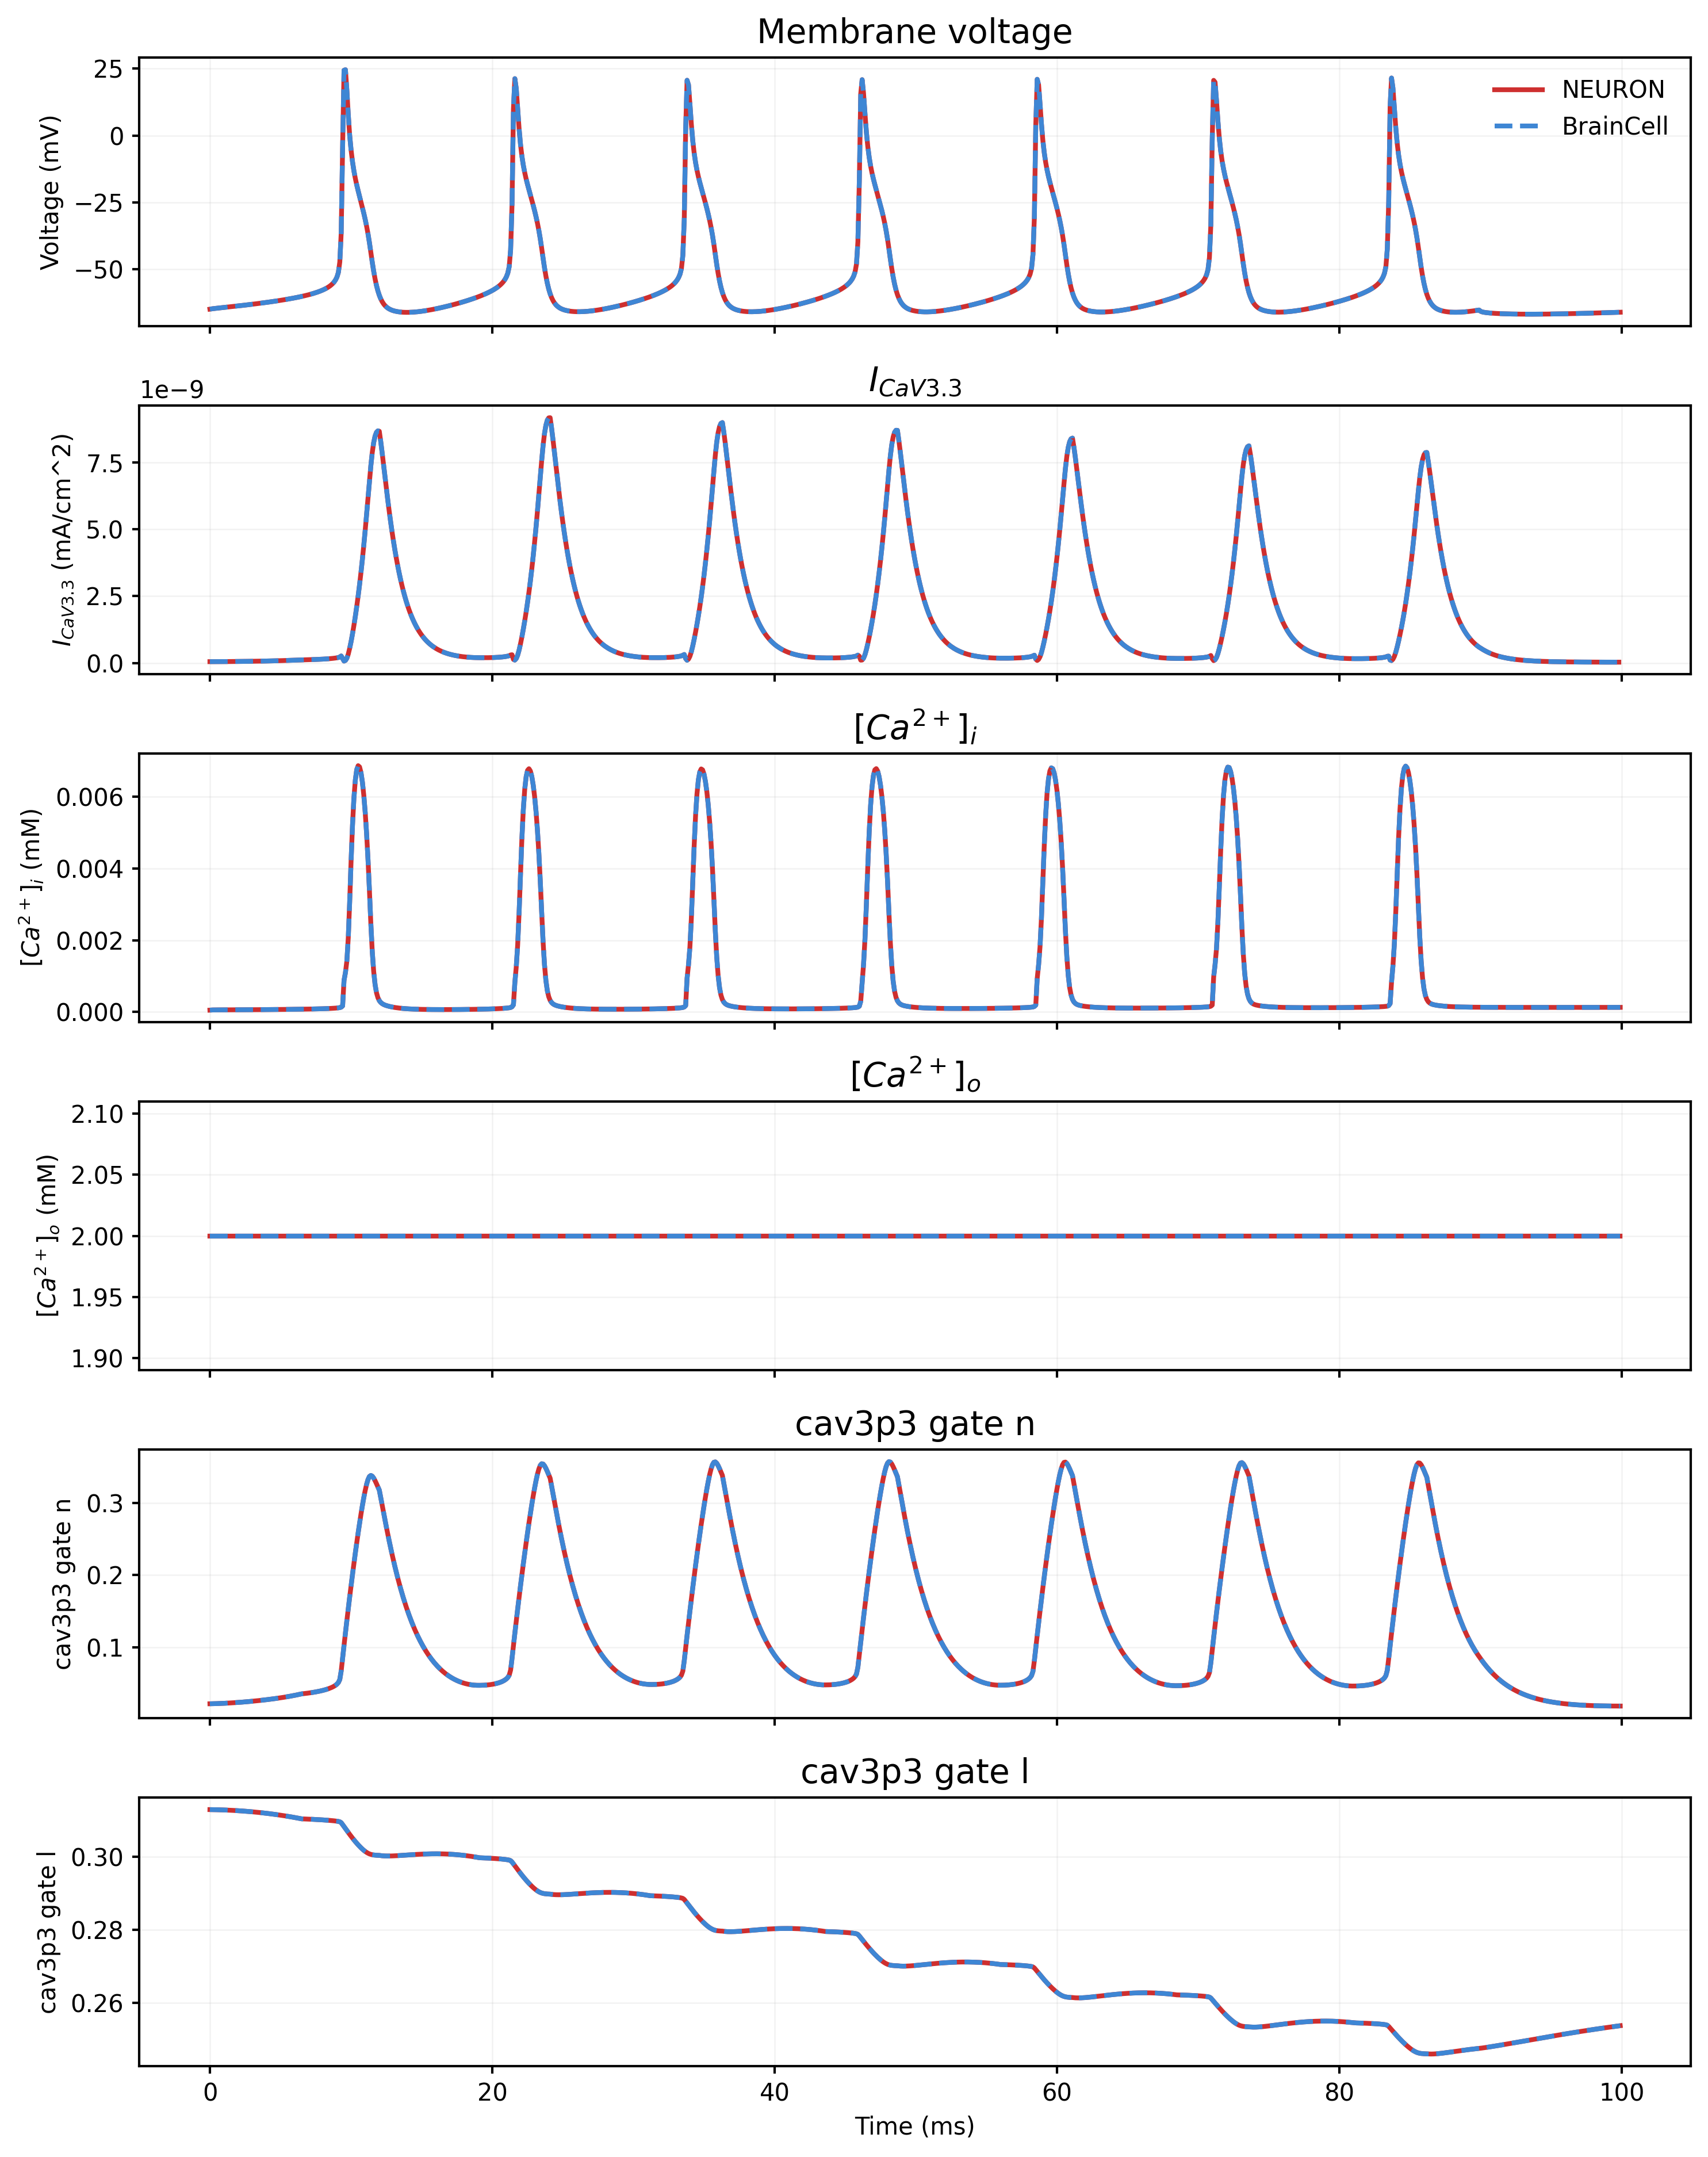

In [8]:
figure_style = {
    "fig_width": 10,
    "panel_height": 2.1,
    "dpi": 300,
    "font_family": "DejaVu Sans",
    "title_size": 14,
    "axis_label_size": 10,
    "tick_label_size": 10,
    "legend_size": 10,
    "line_width": 2,
    "spine_width": 1,
    "tick_width": 1,
    "tick_length": 3.0,
    "grid_alpha": 0.16,
    "neuron_color": "#CE2F2F",
    "braincell_color": "#3E86D4",
    "save_path": None,
}

diag_label = soma_diag_handles.get("label", "Calcium current")
plot_labels = {
    "voltage": "Membrane voltage",
    "ica": diag_label,
    "cai": r"$[Ca^{2+}]_i$",
    "cao": r"$[Ca^{2+}]_o$",
}
for gate in soma_diag_handles.get("gates", []):
    plot_labels[gate] = f"{soma_diag_handles.get('channel', 'channel')} gate {gate}"

plot_specs = [("voltage", reference_time_ms, neuron_soma, braincell_soma, "Voltage (mV)")]
for key in ["ica", "cai", "cao", *soma_diag_handles.get("gates", [])]:
    if key in soma_diag:
        neuron_values, braincell_values, unit_label = soma_diag[key][:3]
        time_ms = soma_diag[key][3] if len(soma_diag[key]) > 3 else reference_time_ms
        ylabel = f"{plot_labels[key]} ({unit_label})" if unit_label else plot_labels[key]
        plot_specs.append((key, time_ms, neuron_values, braincell_values, ylabel))

with plt.rc_context(
    {
        "font.family": figure_style["font_family"],
        "font.size": figure_style["tick_label_size"],
        "axes.linewidth": figure_style["spine_width"],
        "axes.labelsize": figure_style["axis_label_size"],
        "axes.titlesize": figure_style["title_size"],
        "xtick.labelsize": figure_style["tick_label_size"],
        "ytick.labelsize": figure_style["tick_label_size"],
        "legend.fontsize": figure_style["legend_size"],
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    }
):
    fig, axes = plt.subplots(
        len(plot_specs),
        1,
        figsize=(figure_style["fig_width"], figure_style["panel_height"] * len(plot_specs)),
        dpi=figure_style["dpi"],
        sharex=True,
    )
    axes = np.atleast_1d(axes)
    for ax, (key, time_ms, neuron_values, braincell_values, ylabel) in zip(axes, plot_specs):
        n = min(len(time_ms), len(neuron_values), len(braincell_values))
        ax.plot(time_ms[:n], neuron_values[:n], color=figure_style["neuron_color"], lw=figure_style["line_width"], label="NEURON")
        ax.plot(time_ms[:n], braincell_values[:n], color=figure_style["braincell_color"], lw=figure_style["line_width"], ls="--", label="BrainCell")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=figure_style["grid_alpha"], linewidth=0.6)
        ax.tick_params(width=figure_style["tick_width"], length=figure_style["tick_length"])
        ax.set_title(plot_labels.get(key, key))
    axes[-1].set_xlabel("Time (ms)")
    axes[0].legend(frameon=False, loc="best")
    fig.tight_layout()
    if figure_style["save_path"]:
        fig.savefig(figure_style["save_path"], bbox_inches="tight")
    plt.show()

In [9]:
# Optional cleanup when re-running cells in the same kernel.
# neuron_sc.cleanup()